In [1]:
import pandas as pd
import numpy as np

# For ploting the graphs
import matplotlib.pyplot as plt
import seaborn as sns
import csv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning Model 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Machine learning model evaluation
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, confusion_matrix


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

In [2]:
df=pd.read_csv(".csv")

In [4]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [5]:
# Remove the spaces before the column names
df.columns = df.columns.str.strip()
#Unique values in the Label target column

df.loc[:,'Label'].unique()

array(['BENIGN', 'DDoS', nan], dtype=object)

In [59]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [60]:
# Assuming your DataFrame is named 'df' and the column with labels is 'label'
df = df.dropna(subset=['Label'])


In [61]:
# Checking the Unique values again after the removal of nan values in the Label target column

df.loc[:,'Label'].unique()

array(['BENIGN', 'DDoS'], dtype=object)

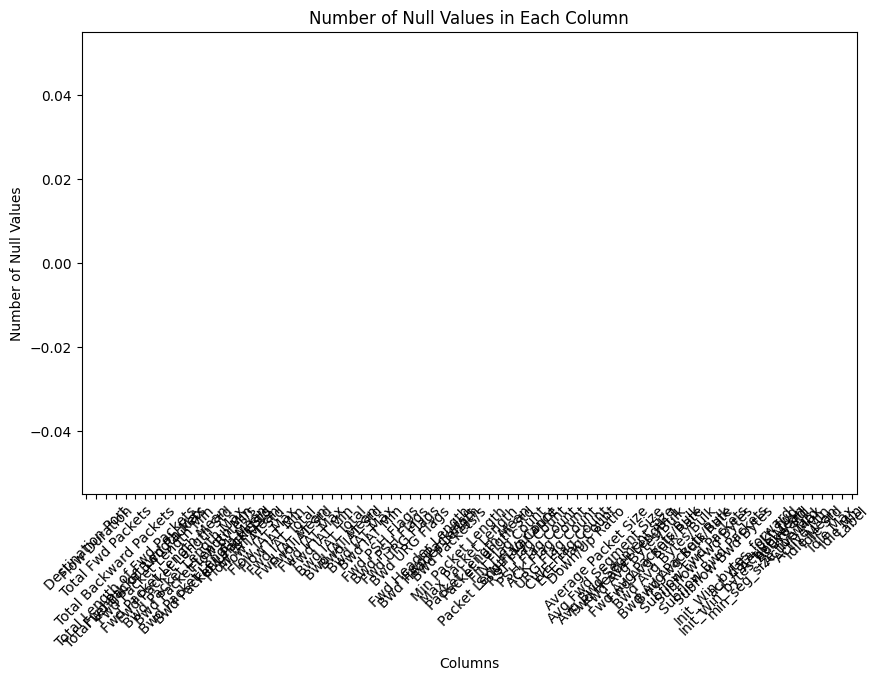

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df'
# Count the number of null values in each column
null_counts = df.isnull().sum()

# Plot the null counts
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Null Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.xticks(rotation=45)
plt.show()


In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode labels
df['Label'] = LabelEncoder().fit_transform(df['Label'])

# Define features and target
X = df.drop('Label', axis=1)
y = df['Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [72]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1 score
# Here, 1 is the positive class (DDoS)
precision = precision_score(y_test, y_pred, pos_label=1)  # Positive class is DDoS
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Accuracy: 0.9995
Precision: 1.0000
Recall: 0.9990
F1 Score: 0.9995


In [70]:
import lime
import lime.lime_tabular
import numpy as np



# Initialize the LIME explainer for tabular data
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['BENIGN', 'DDoS'],
    mode='classification'
)

# Choose a sample from X_test to explain
sample_index = 0  # for example, the first sample in X_test
sample = X_test.iloc[sample_index]

# Generate explanation for the selected sample
explanation = explainer.explain_instance(
    data_row=sample,
    predict_fn=rf_model.predict_proba
)

# Visualize the explanation
explanation.show_in_notebook(show_table=True)
# Or, save the explanation as an HTML file for viewing in a browser
explanation.save_to_file("lime_explanation.html")



C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be 

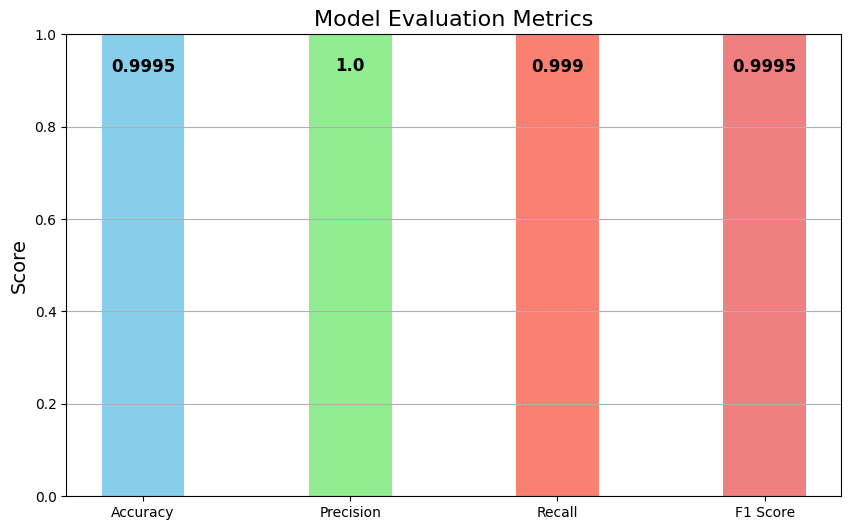

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

# Create a bar plot with slimmer bars
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'lightcoral'], width=0.4)  # Adjusted width

# Add value annotations on the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval - 0.05, round(yval, 4),  # Positioned slightly lower
             ha='center', va='top', fontsize=12, fontweight='bold', color='black')

# Set labels and title
plt.ylim(0, 1)  # Set y-axis limit from 0 to 1
plt.ylabel('Score', fontsize=14)
plt.title('Model Evaluation Metrics', fontsize=16)
plt.grid(axis='y')

# Show the plot
plt.show()


C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feat

<module 'matplotlib.pyplot' from 'C:\\Users\\dell\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

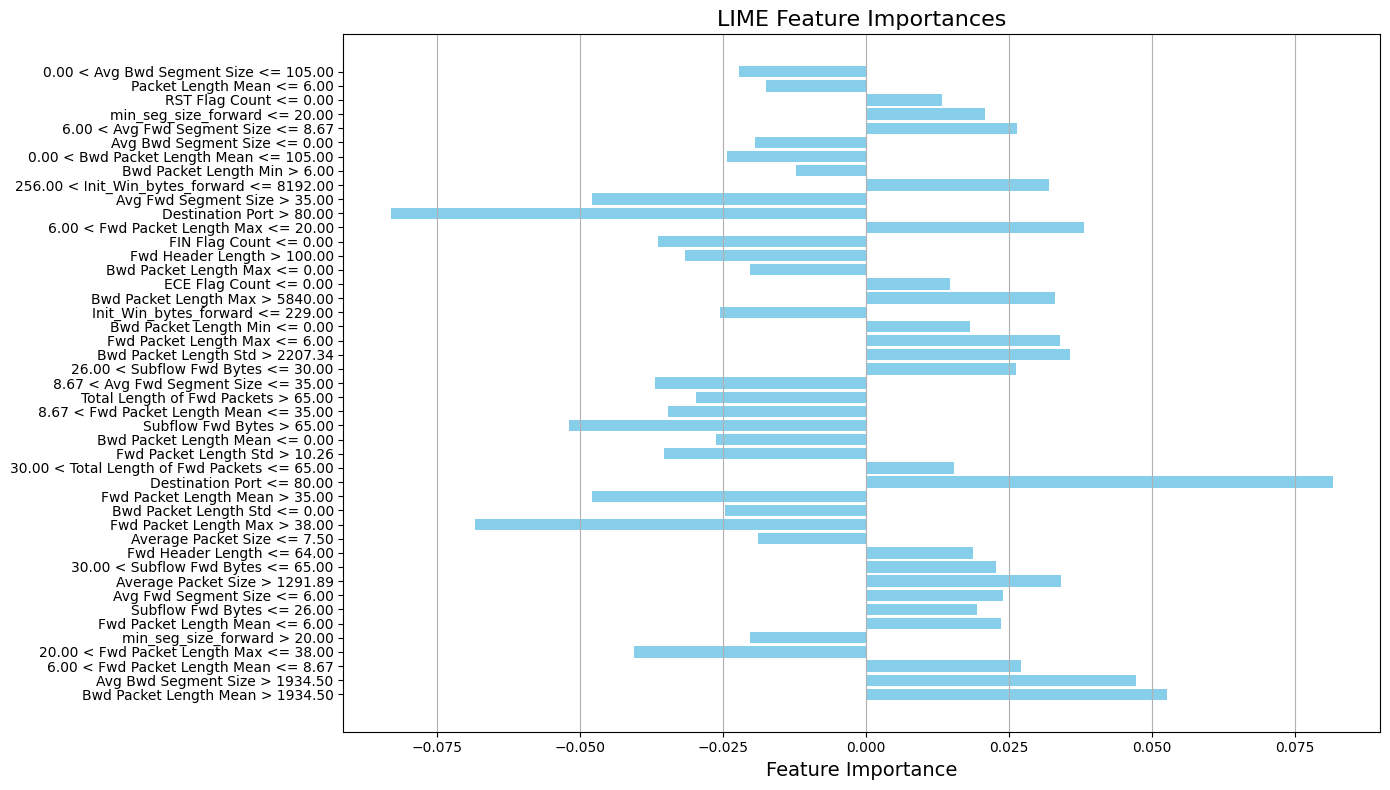

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import lime
from lime.lime_tabular import LimeTabularExplainer

# Assuming you have your model, X_test, and y_test already defined
# Create the LIME explainer
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns.tolist(), class_names=['BENIGN', 'DDoS'], mode='classification')

# Get predictions and calculate accuracy
y_pred = rf_model.predict(X_test)
accuracy = np.mean(y_pred == y_test)

# Prepare to store feature importances
feature_importances = []

# Generate explanations for a sample of instances (you can adjust the number of instances)
for i in range(10):  # Change to however many you want to analyze
    exp = explainer.explain_instance(X_test.values[i], rf_model.predict_proba)
    feature_importances.append(exp.as_list())

# Extract feature importances for visualization
features = [f[0] for fi in feature_importances for f in fi]
importances = [f[1] for fi in feature_importances for f in fi]

# Aggregate importances
unique_features = list(set(features))
aggregated_importances = [importances[features.index(f)] for f in unique_features]

# Plotting
plt.figure(figsize=(14, 8))  # Increased figure size for better visibility
plt.barh(unique_features, aggregated_importances, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.title('LIME Feature Importances', fontsize=16)
plt.grid(axis='x')

# Rotate the y-axis labels for better readability
plt.yticks(rotation=0)  # Set rotation to 0 for horizontal text
plt.tight_layout()  # Adjust layout to prevent overlap

# Show the plot
plt


C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feat

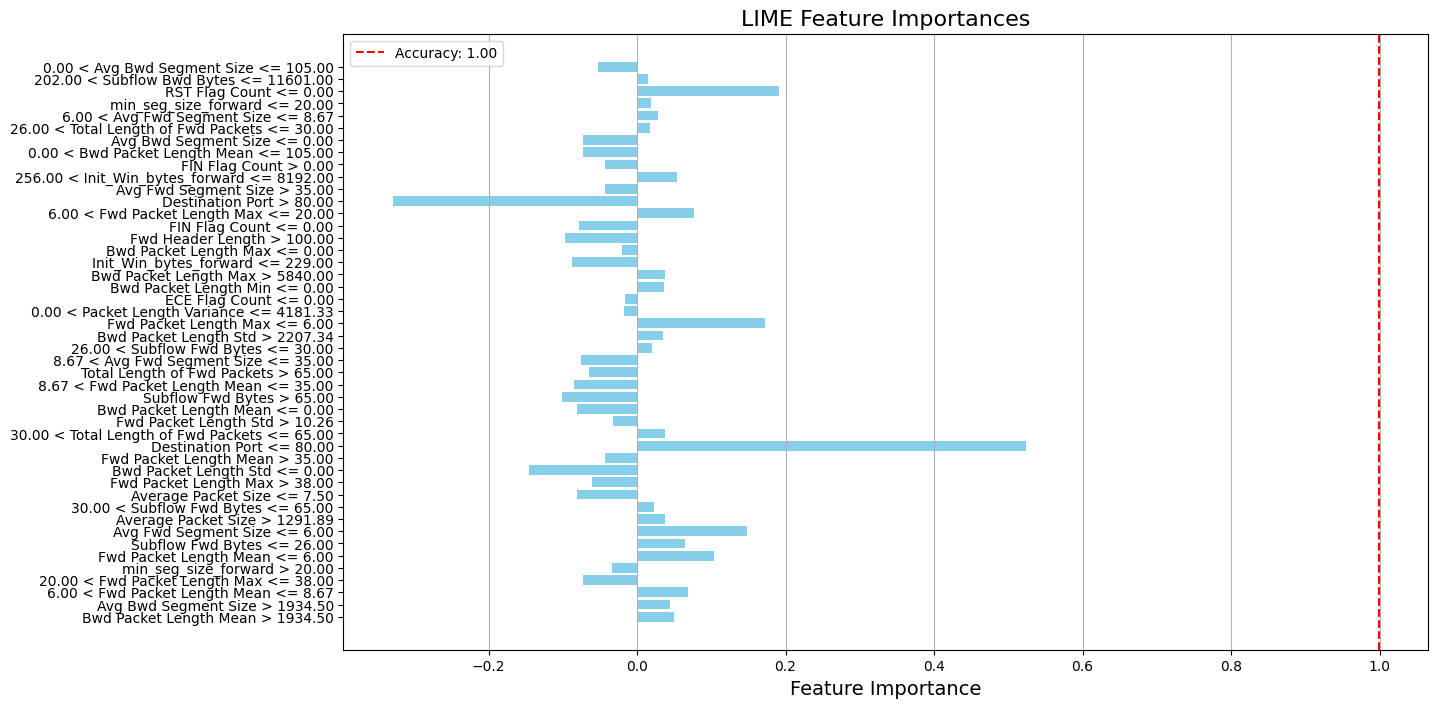

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Create the LIME explainer as before
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns.tolist(), 
                                   class_names=['BENIGN', 'DDoS'], mode='classification')

# Get predictions and calculate accuracy
y_pred = rf_model.predict(X_test)
accuracy = np.mean(y_pred == y_test)

# Prepare to store feature importances
feature_importances = []

# Generate explanations for a sample of instances
for i in range(10):  # Adjust the number of instances as needed
    exp = explainer.explain_instance(X_test.values[i], rf_model.predict_proba)
    feature_importances.append(exp.as_list())

# Extract feature importances for visualization
features = [f[0] for fi in feature_importances for f in fi]
importances = [f[1] for fi in feature_importances for f in fi]

# Aggregate importances
unique_features = list(set(features))
aggregated_importances = [sum([importances[features.index(f)] for f in features if f == unique]) for unique in unique_features]

# Plotting
plt.figure(figsize=(14, 8))  # Increased figure size for better visibility
bars = plt.barh(unique_features, aggregated_importances, color='skyblue')
plt.xlabel('Feature Importance', fontsize=14)
plt.title('LIME Feature Importances', fontsize=16)

# Add accuracy as a vertical line
plt.axvline(x=accuracy, color='red', linestyle='--', label=f'Accuracy: {accuracy:.2f}')
plt.legend()

# Grid for better readability
plt.grid(axis='x')

# Show the plot
plt.show()


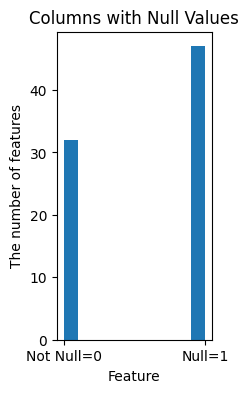

In [8]:
#Checking the null values in the dataset.
plt.figure(1,figsize=( 2,4))
plt.hist( df.isna().sum())
# Set the title and axis labels
plt.xticks([0, 1], labels=['Not Null=0', 'Null=1'])
plt.title('Columns with Null Values')
plt.xlabel('Feature')
plt.ylabel('The number of features')

# Show the plot
plt.show()

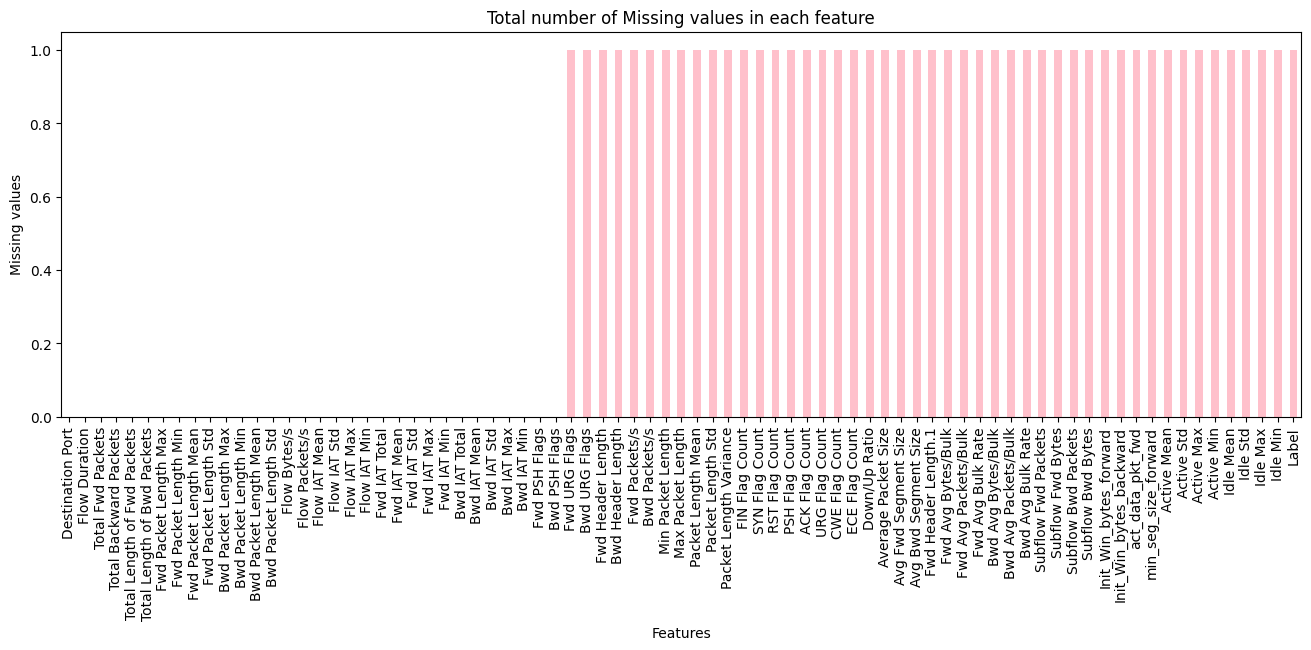

In [9]:
def plotMissingValues(dataframe):
    missing_values = dataframe.isnull().sum()  # Counting null values for each column
    fig = plt.figure(figsize=(16, 5))
    missing_values.plot(kind='bar', color='pink')
    plt.xlabel("Features")
    plt.ylabel("Missing values")
    plt.title("Total number of Missing values in each feature")
    plt.show()

plotMissingValues(df)

In [82]:
#Prepare to store feature importances
feature_importances = []

# Generate explanations for a sample of instances
for i in range(10):  # Analyzing 10 instances
    exp = explainer.explain_instance(X_test.values[i], rf_model.predict_proba)
    feature_importances.append(exp.as_list())

# Extract feature importances
features = [f[0] for fi in feature_importances for f in fi]
importances = [f[1] for fi in feature_importances for f in fi]

# Aggregate importances
importance_dict = {}
for f, imp in zip(features, importances):
    if f in importance_dict:
        importance_dict[f] += imp
    else:
        importance_dict[f] = imp

# Sort features by importance
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Prepare for accuracy comparison
num_features = len(sorted_features)
accuracies = []

# Calculate accuracy with increasing number of top features
for i in range(1, num_features + 1):
    top_features = [f[0] for f in sorted_features[:i]]
    X_train_subset = X_train[top_features]
    X_test_subset = X_test[top_features]
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_subset, y_train)
    y_pred_subset = model.predict(X_test_subset)
    acc = accuracy_score(y_test, y_pred_subset)
    accuracies.append(acc)

# Plotting accuracy vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_features + 1), accuracies, marker='o', color='skyblue', label='Accuracy')
plt.xticks(range(1, num_features + 1), [f[0] for f in sorted_features], rotation=45)
plt.xlabel('Number of Top Features', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Accuracy vs. Number of Top Features', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feat

KeyError: "None of [Index(['Destination Port <= 80.00'], dtype='object')] are in the [columns]"

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feat

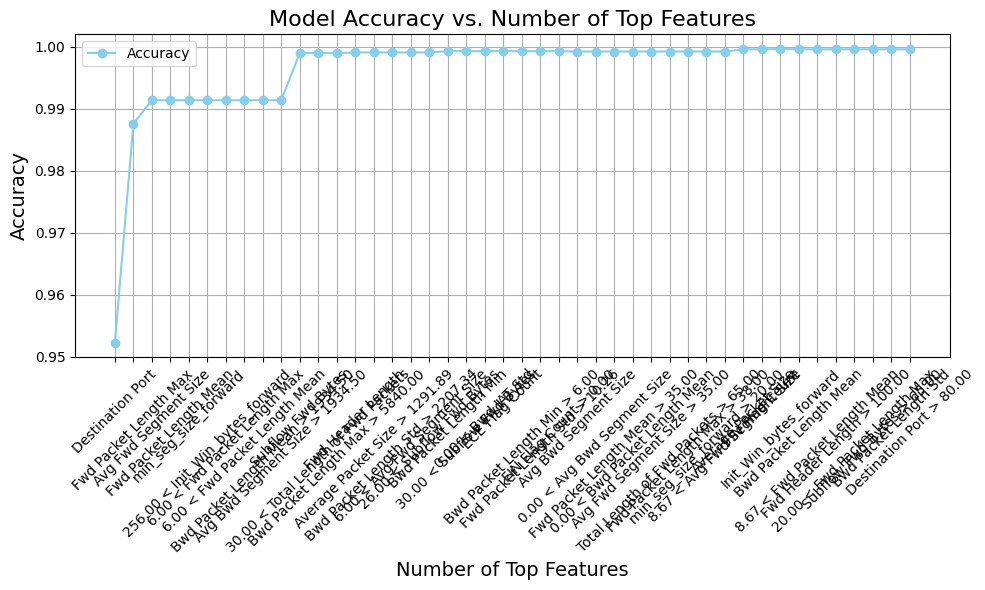

In [83]:
# Create the LIME explainer
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns.tolist(), class_names=['BENIGN', 'DDoS'], mode='classification')

# Prepare to store feature importances
importance_dict = {}

# Generate explanations for a sample of instances
for i in range(10):  # Analyzing 10 instances
    exp = explainer.explain_instance(X_test.values[i], rf_model.predict_proba)
    for feature, importance in exp.as_list():
        # Normalize feature names to match your DataFrame
        feature_name = feature.split(' <= ')[0]  # Assuming you want just the feature name
        if feature_name in importance_dict:
            importance_dict[feature_name] += importance
        else:
            importance_dict[feature_name] = importance

# Sort features by importance
sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)

# Prepare for accuracy comparison
num_features = len(sorted_features)
accuracies = []

# Calculate accuracy with increasing number of top features
for i in range(1, num_features + 1):
    top_features = [f[0] for f in sorted_features[:i] if f[0] in X_train.columns]  # Ensure features exist
    if len(top_features) == 0:
        continue  # Skip if no valid features

    X_train_subset = X_train[top_features]
    X_test_subset = X_test[top_features]

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_subset, y_train)
    y_pred_subset = model.predict(X_test_subset)
    acc = accuracy_score(y_test, y_pred_subset)
    accuracies.append(acc)

# Plotting accuracy vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', color='skyblue', label='Accuracy')
plt.xticks(range(1, len(accuracies) + 1), [f[0] for f in sorted_features[:len(accuracies)]], rotation=45)
plt.xlabel('Number of Top Features', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Model Accuracy vs. Number of Top Features', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [10]:
## Removing the null values
data_f=df.dropna()

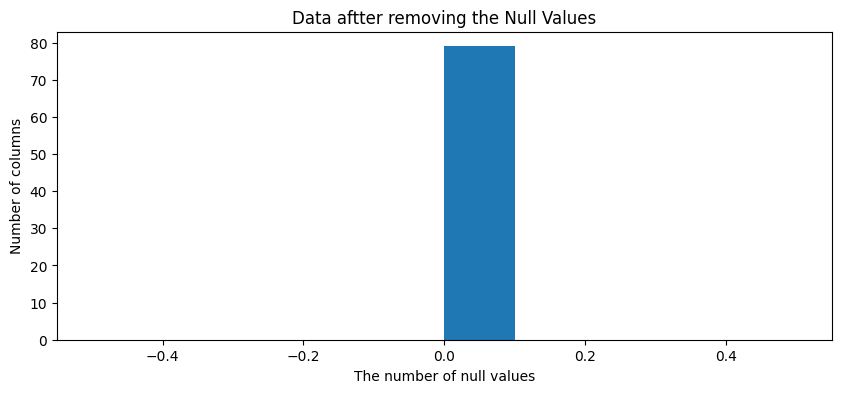

In [11]:
#Checking the null values in the dataset.
plt.figure(1,figsize=( 10,4))
plt.hist( data_f.isna().sum())
# Set the title and axis labels
plt.title('Data aftter removing the Null Values')
plt.xlabel('The number of null values')
plt.ylabel('Number of columns')

# Show the plot
plt.show()

In [12]:
data_f.shape

(66236, 79)

In [13]:
pd.set_option('use_inf_as_na', True)  # Treat inf as NaN
null_values=data_f.isnull().sum()  # Check for NaN values

C:\Users\dell\AppData\Local\Temp\ipykernel_15204\783324428.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('use_inf_as_na', True)  # Treat inf as NaN


In [14]:
# To know the data types of the columns

(data_f.dtypes=='object')

Destination Port               False
Flow Duration                  False
Total Fwd Packets              False
Total Backward Packets         False
Total Length of Fwd Packets    False
                               ...  
Idle Mean                      False
Idle Std                       False
Idle Max                       False
Idle Min                       False
Label                           True
Length: 79, dtype: bool

In [15]:
# Convert the labels in the DataFrame to numerical values
data_f['Label'] = data_f['Label'].map({'BENIGN': 0, 'DDoS': 1})

C:\Users\dell\AppData\Local\Temp\ipykernel_15204\172444858.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_f['Label'] = data_f['Label'].map({'BENIGN': 0, 'DDoS': 1})


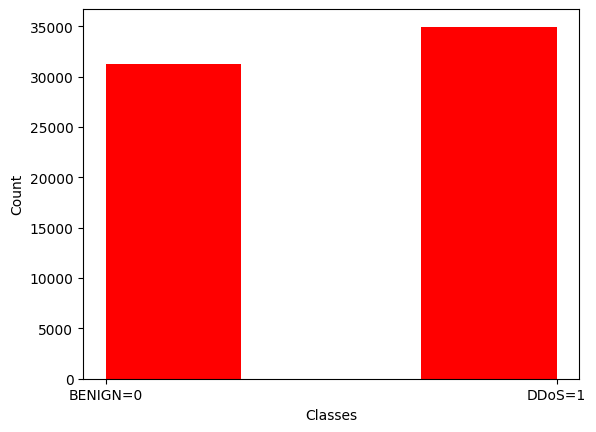

In [18]:
# Print the DataFrame

plt.hist(data_f['Label'], bins=[0, 0.3,0.7,1], color='red')  # Specify bins as [0, 1]
plt.xticks([0, 1], labels=['BENIGN=0', 'DDoS=1'])
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

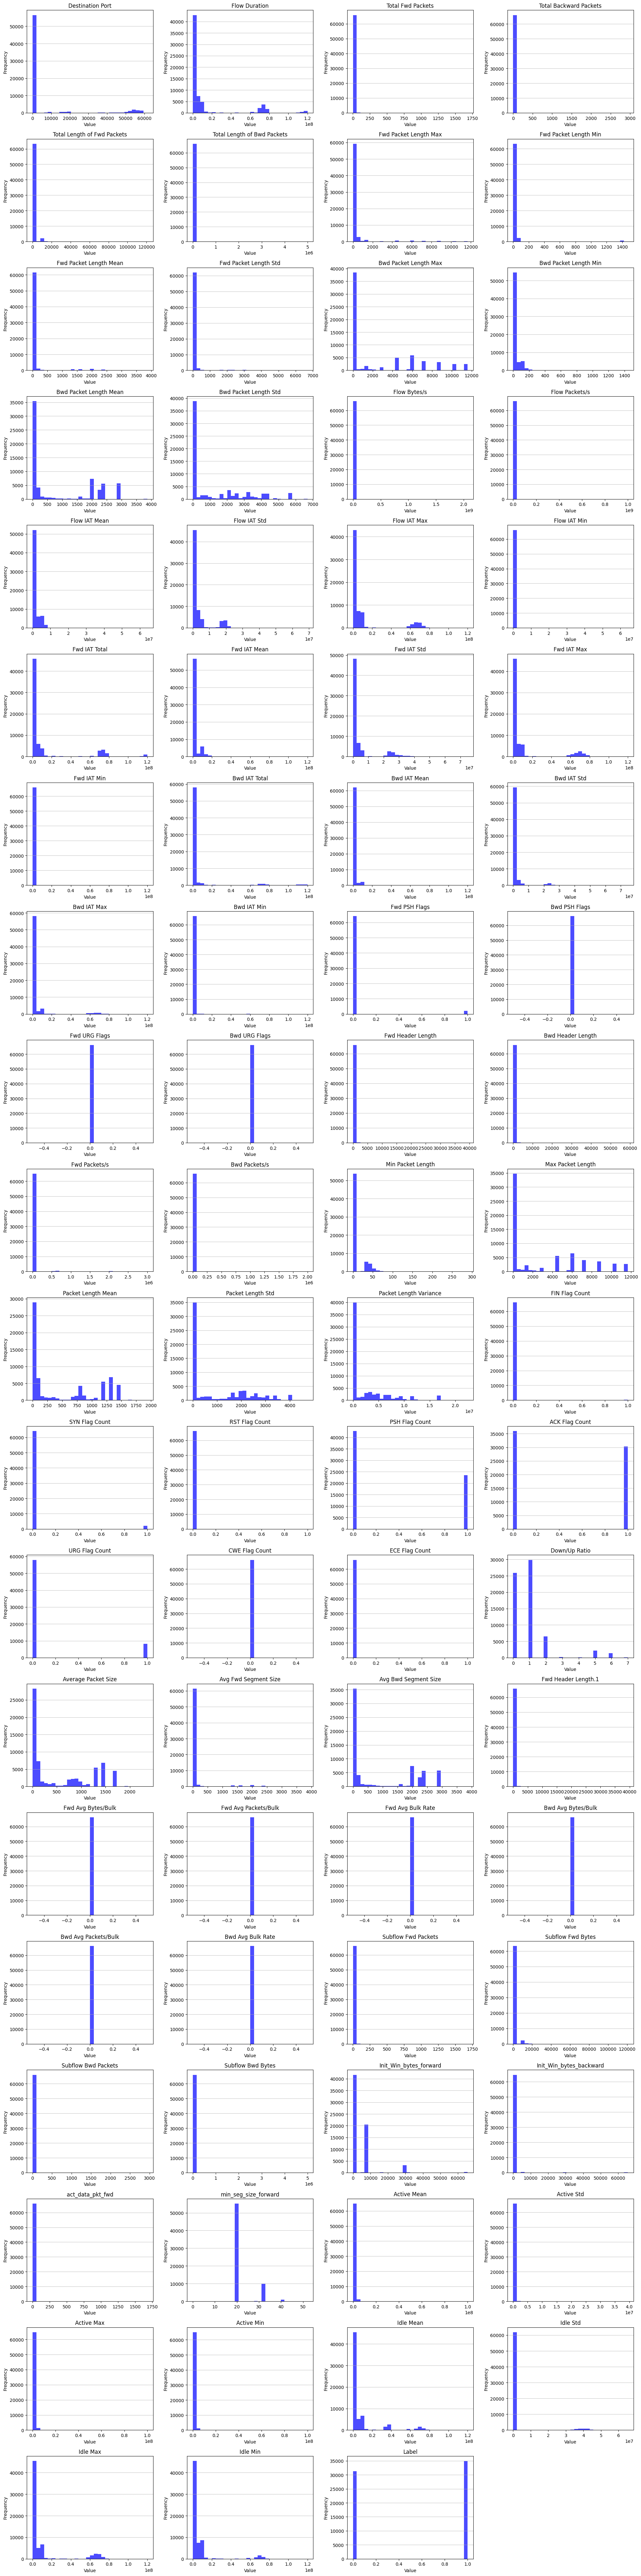

In [19]:
import matplotlib.pyplot as plt

# Number of features
num_features = data_f.shape[1]

# Determine grid size for subplots
ncols = 4  # Number of columns in the grid
nrows = (num_features + ncols - 1) // ncols  # Calculate the required number of rows

plt.figure(figsize=(20, nrows * 4))  # Set the figure size

for i, col in enumerate(data_f.columns):
    plt.subplot(nrows, ncols, i + 1)  # Create a subplot for each feature
    plt.hist(data_f[col], bins=30, alpha=0.7, color='blue')  # Adjust the number of bins
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)  # Add grid lines for better readability

plt.tight_layout()  # Adjust the layout to prevent overlap
plt.show()


In [20]:
# Split data into features and target variable
X = data_f.drop('Label', axis=1)
y = data_f['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [21]:
print("The train dataset size = ",X_train.shape)
print("The test dataset size = ",X_test.shape)

The train dataset size =  (46365, 78)
The test dataset size =  (19871, 78)


In [22]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

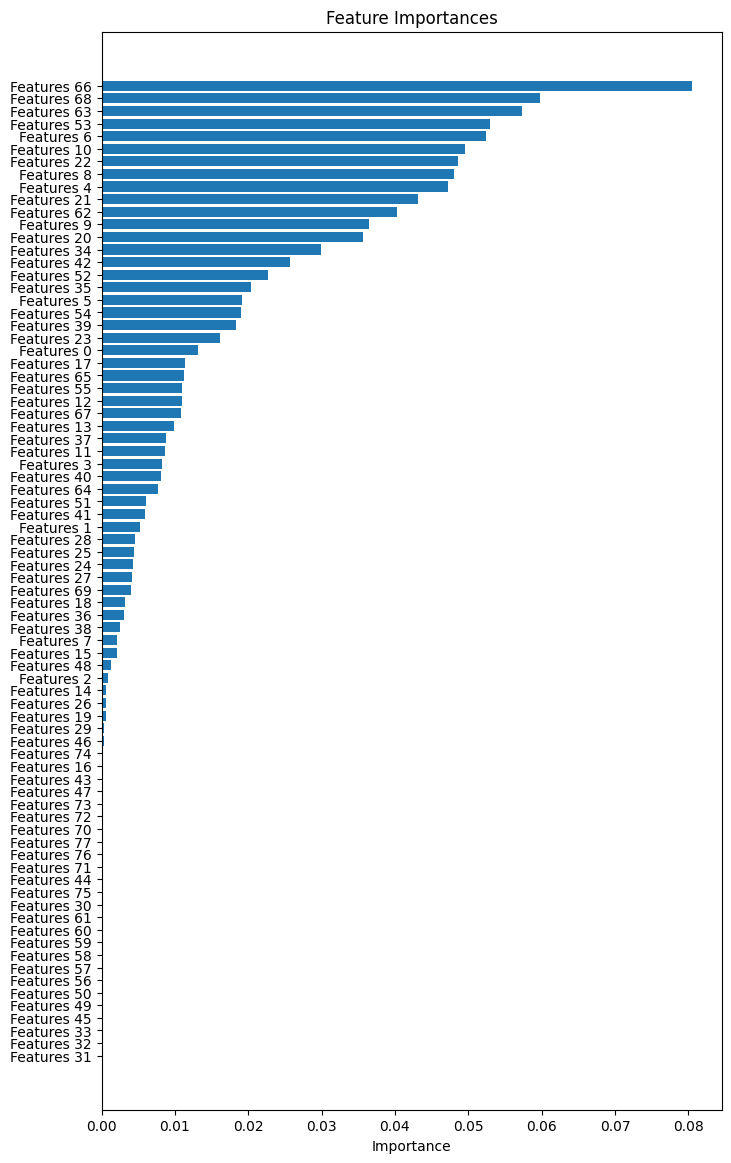

In [23]:
# Getting feature importances from the trained model
importances = rf_model.feature_importances_

# Getting the indices of features sorted by importance
indices = sorted(range(len(importances)), key=lambda i: importances[i], reverse=False)
feature_names = [f"Features {i}" for i in indices]  # Replace with your column names

# Plotting feature importances horizontally
plt.figure(figsize=(8, 14))
plt.barh(range(X_train.shape[1]), importances[indices], align="center")
plt.yticks(range(X_train.shape[1]), feature_names)
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

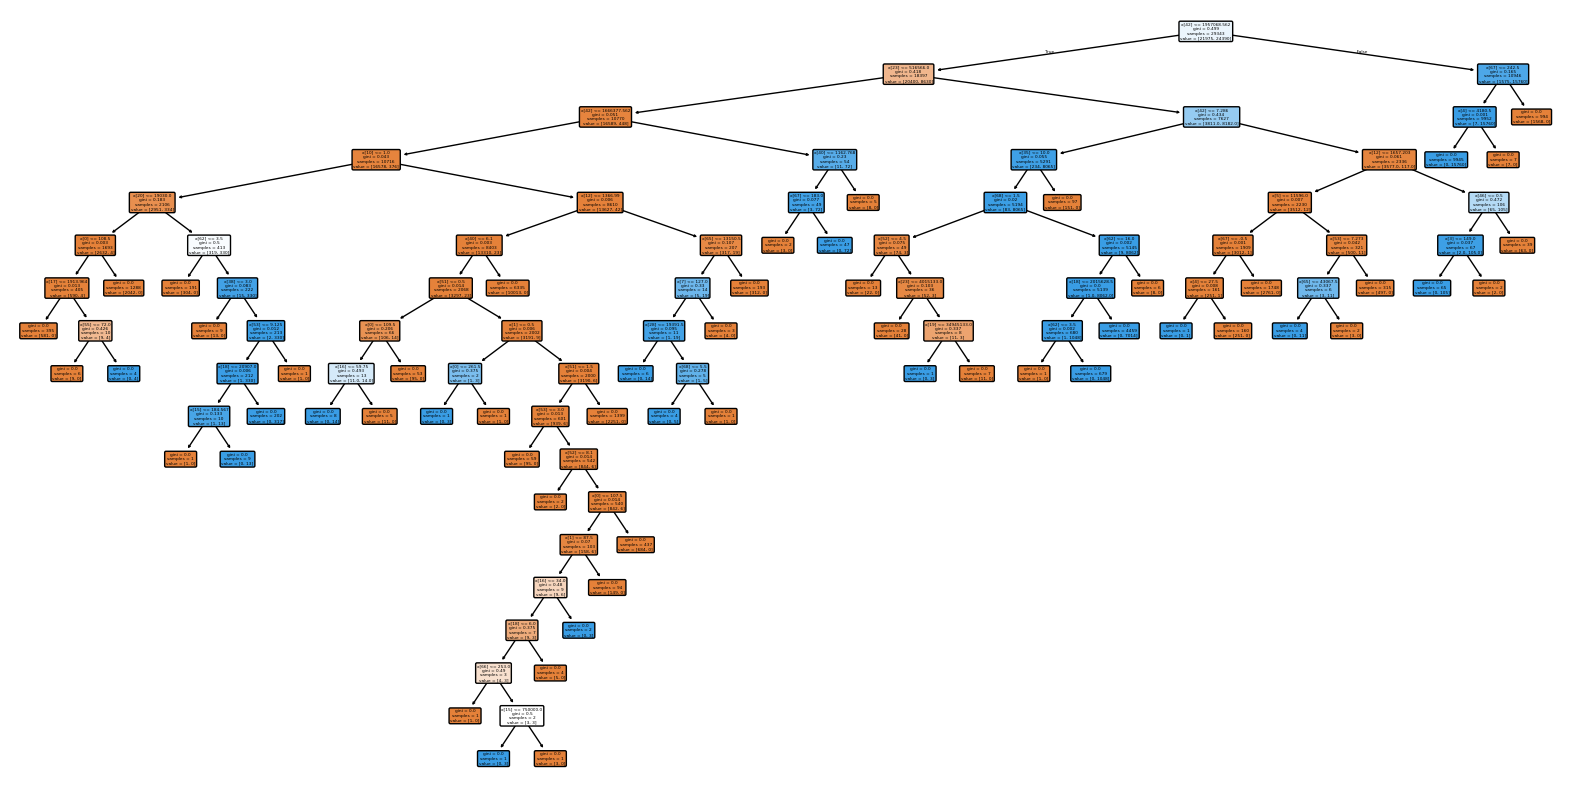

In [24]:
from sklearn.tree import plot_tree

estimator = rf_model.estimators_[0]  # Selecting the first estimator from the random forest model


plt.figure(figsize=(20, 10))
plot_tree(estimator, filled=True, rounded=True)
plt.show()

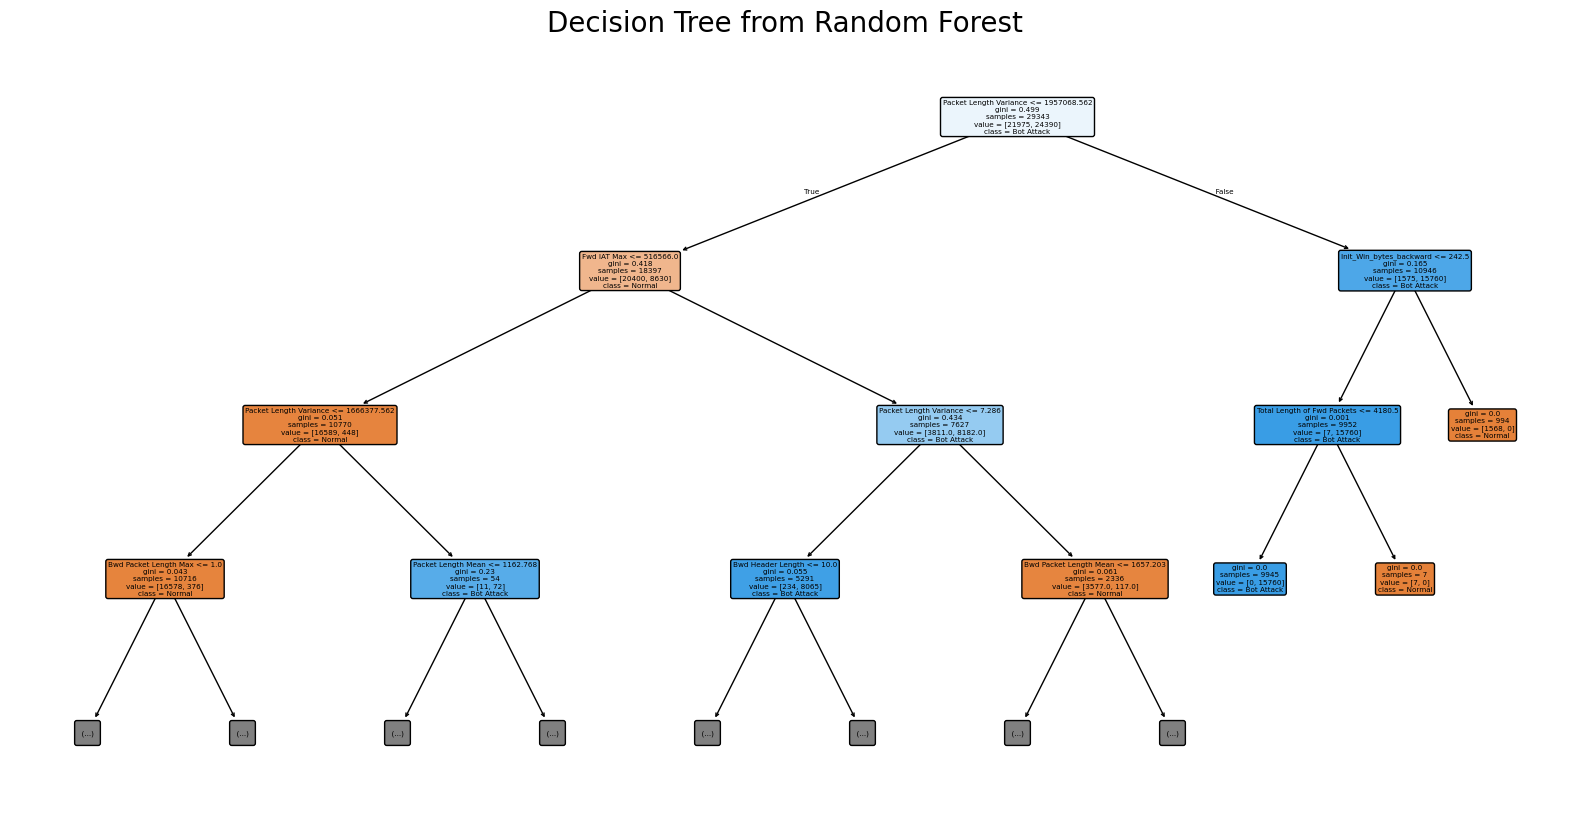

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Assuming rf_model is your trained Random Forest model
estimator = rf_model.estimators_[0]  # Selecting the first estimator from the random forest model

# Set up the plot
plt.figure(figsize=(20, 10))
plot_tree(estimator, 
          filled=True, 
          rounded=True, 
          feature_names=X.columns,  # Use your feature names
          class_names=['Normal', 'Bot Attack'],  # Update with your class names
          max_depth=3)  # Limit the depth for better visibility

# Add title and labels
plt.title('Decision Tree from Random Forest', fontsize=20)
plt.xlabel('Feature', fontsize=15)
plt.ylabel('Node', fontsize=15)

# Show the plot
plt.show()


In [26]:
# Function to generate and display a detailed confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

In [40]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print('\nRandom Forest Metrics:')
print(f'Accuracy: {rf_accuracy:.4f}')
print(f'F1 Score: {rf_f1:.4f}')
print(f'Precision: {rf_precision:.4f}')
print(f'Recall: {rf_recall:.4f}')


Random Forest Metrics:
Accuracy: 0.9995
F1 Score: 0.9995
Precision: 1.0000
Recall: 0.9990


In [43]:
!pip install xgboost


In [44]:
import xgboost as xgb
from xgboost import XGBClassifier

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)


C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:04:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [45]:
from sklearn.svm import SVC

# Support Vector Machine
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)


In [47]:
!pip install tensorflow


  You can safely remove it manually.
  You can safely remove it manually.


   ---------------------------------------- 0.0/385.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/385.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/385.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/385.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/385.2 MB 762.0 kB/s eta 0:08:25
   ---------------------------------------- 0.8/385.2 MB 882.6 kB/s eta 0:07:16
   ---------------------------------------- 0.8/385.2 MB 882.6 kB/s eta 0:07:16
   ---------------------------------------- 1.0/385.2 MB 729.5 kB/s eta 0:08:47
   ---------------------------------------- 1.0/385.2 MB 729.5 kB/s eta 0:08:47
   ---------------------------------------- 1.3/385.2 MB 677.8 kB/s eta 0:09:27
   ---------------------------------------- 1.3/385.2 MB 677.8 kB/s eta 0:09:27
   ---------------------------------------- 1.3/385.2 MB 677.8 kB/s eta 0:09:27
   ---------------------------------------- 1.6/385.2 MB 625.9 kB/s eta 0:10

In [55]:


import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Assuming X_train is already defined as your input features
# Check if X_train is a NumPy array, if not convert it
if not isinstance(X_train, np.ndarray):
    X_train = np.array(X_train)

# Reshape X_train to have shape (samples, time_steps, features)
# If you want to treat the entire sequence as a single time step:
X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))

# Check the shape
print("X_train reshaped:", X_train_reshaped.shape)

# Create the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=50, input_shape=(1, X_train.shape[1])))  # 1 time step

# Output layer for binary classification
gru_model.add(Dense(1, activation='sigmoid'))

# Compile the model
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model on training data
gru_model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32)

# Reshape X_test in the same way
if not isinstance(X_test, np.ndarray):
    X_test = np.array(X_test)
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Predict using the GRU model
gru_pred = gru_model.predict(X_test_reshaped)
gru_pred = (gru_pred > 0.5).astype(int)

print(gru_pred)







X_train reshaped: (46365, 1, 78)


ValueError: object __array__ method not producing an array

<Figure size 800x600 with 0 Axes>

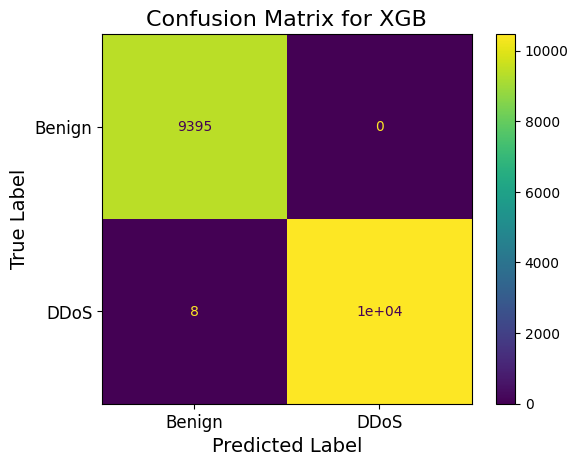

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test is your true labels and rf_pred is your predictions
cm = confusion_matrix(y_test, xgb_pred, labels=[0, 1])  # Use appropriate labels for your classes

# Create a Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'DDoS'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.viridis, colorbar=True)
plt.title('Confusion Matrix for XGB', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


<Figure size 800x600 with 0 Axes>

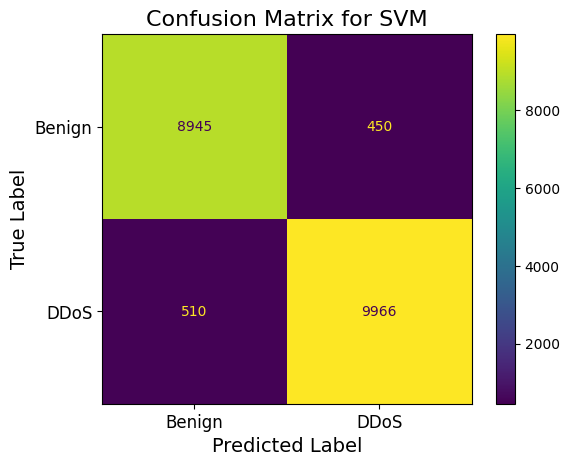

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test is your true labels and rf_pred is your predictions
cm = confusion_matrix(y_test, svm_pred, labels=[0, 1])  # Use appropriate labels for your classes

# Create a Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'DDoS'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.viridis, colorbar=True)
plt.title('Confusion Matrix for SVM', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


<Figure size 800x600 with 0 Axes>

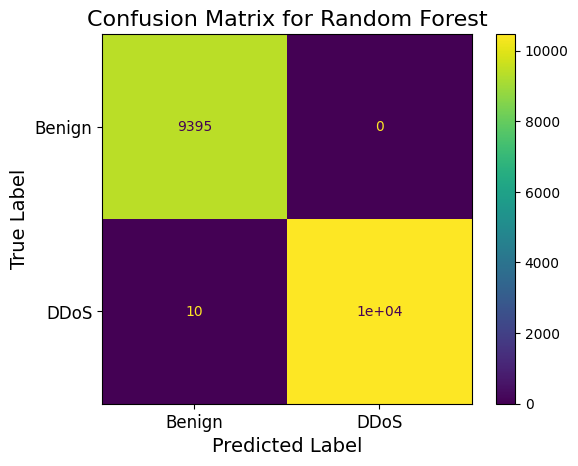

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test is your true labels and rf_pred is your predictions
cm = confusion_matrix(y_test, rf_pred, labels=[0, 1])  # Use appropriate labels for your classes

# Create a Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'DDoS'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.viridis, colorbar=True)
plt.title('Confusion Matrix for Random Forest', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [31]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
print('\nLogistic Regression Metrics:')
print(f'Accuracy: {lr_accuracy:.4f}')
print(f'F1 Score: {lr_f1:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall: {lr_recall:.4f}')


Logistic Regression Metrics:
Accuracy: 0.9448
F1 Score: 0.9500
Precision: 0.9096
Recall: 0.9941


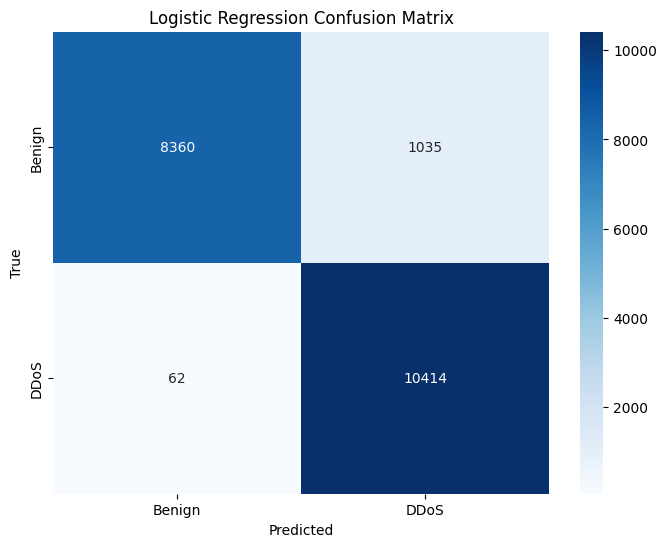

In [33]:
# Confusion Matrix for Logistic Regression
plot_confusion_matrix(y_test, lr_pred, ['Benign', 'DDoS'], 'Logistic Regression Confusion Matrix')

In [34]:
nn_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10, random_state=42)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)

C:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


In [35]:
nn_accuracy = accuracy_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred)
nn_recall = recall_score(y_test, nn_pred)

print('\nNeural Network Metrics:')
print(f'Accuracy: {nn_accuracy:.4f}')
print(f'F1 Score: {nn_f1:.4f}')
print(f'Precision: {nn_precision:.4f}')
print(f'Recall: {nn_recall:.4f}')


Neural Network Metrics:
Accuracy: 0.9827
F1 Score: 0.9837
Precision: 0.9760
Recall: 0.9915


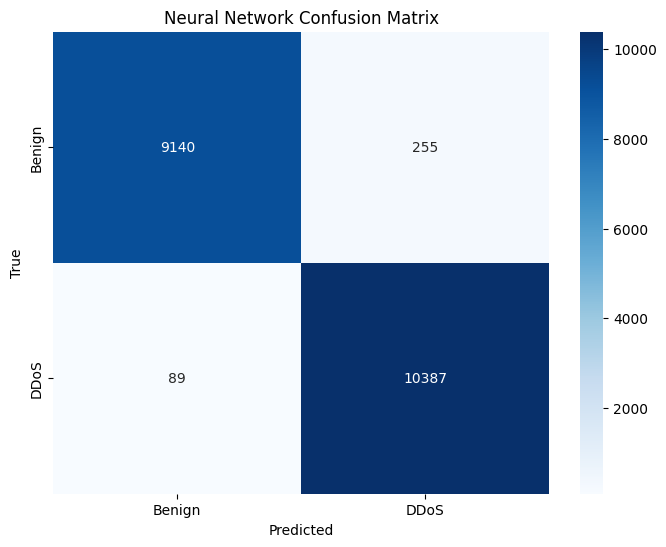

In [36]:
# Confusion Matrix for Neural Network
plot_confusion_matrix(y_test, nn_pred, ['Benign', 'DDoS'], 'Neural Network Confusion Matrix')

In [58]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# Step 1: Train the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Step 2: Get predictions from the Gradient Boosting model
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

# Step 3: Create new features for MLP using the predictions from Gradient Boosting
X_train_combined = np.column_stack((X_train, gb_train_pred))
X_test_combined = np.column_stack((X_test, gb_test_pred))

# Step 4: Train the MLP model using the new combined features
mlp_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=10, random_state=42)
mlp_model.fit(X_train_combined, y_train)

# Step 5: Make predictions with the MLP model
mlp_pred = mlp_model.predict(X_test_combined)

# Step 6: Evaluate the model
accuracy = accuracy_score(y_test, mlp_pred)
print(f"Combined Model Accuracy: {accuracy:.2f}")


ValueError: Found array with dim 3. GradientBoostingClassifier expected <= 2.

In [37]:
# Random Forest
rf_proba = rf_model.predict_proba(X_test)

# Logistic Regression
lr_proba = lr_model.predict_proba(X_test)



# Neural Network
nn_proba = nn_model.predict_proba(X_test)

In [38]:
# Combine predictions for ROC curve



# Calculate ROC curve for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba[:, 1])
rf_auc = auc(rf_fpr, rf_tpr)

# Calculate ROC curve for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba[:, 1])
lr_auc = auc(lr_fpr, lr_tpr)



# Calculate ROC curve for Neural Network
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_proba[:, 1])
nn_auc = auc(nn_fpr, nn_tpr)

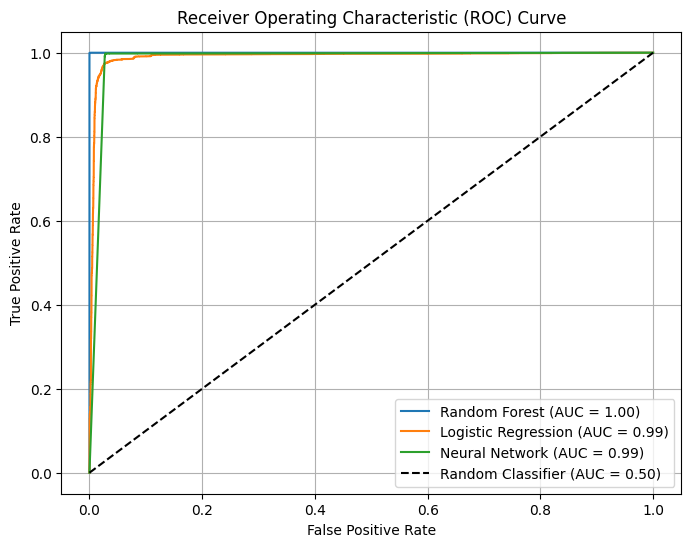

In [39]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(nn_fpr, nn_tpr, label=f'Neural Network (AUC = {nn_auc:.2f})')

# Plot ROC curve for random classifier (50% area)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()